# Dataset overview — appendix figures

Descriptive figures for all three datasets used in the model-collapse
experiments (`local-docs/experimental_design.md`, Dataset selection §2):
Tier A (controlled synthetic data), and the two Tier B real-data
validations, Covertype and Adult/Census Income.

This notebook is purely **descriptive** — it characterizes the data itself
(spread, class/group balance, correlation structure) and does not fit or
evaluate any recursive-collapse loop. Figures are saved to `figures/` at
300 DPI as PNG, suitable for direct inclusion in a paper appendix (swap
`save_fig`'s `.png` for `.pdf` for vector output if preferred).

Color choices follow this project's dataviz skill: categorical hues are
assigned in a fixed order and validated for colorblind safety
(`node scripts/validate_palette.js` — worst adjacent CVD ΔE 9.1, PASS);
correlation heatmaps use a blue↔red diverging scale with a neutral gray
midpoint, never a rainbow; PCA scatter plots cap distinguishable classes at
three (blue, orange, and a muted "other" gray) since scatter plots fall
under the palette's stricter *all-pairs* validation, not the *adjacent*
validation bar/line charts get — Covertype's 7 classes are shown as its two
rare classes highlighted against everything else bucketed as "other",
rather than a 7-hue soup no palette can make colorblind-safe.

In [1]:
import sys
from pathlib import Path


def find_repo_root(marker="requirements.txt"):
    """Walk up from the kernel's cwd looking for a repo-root marker.
    Notebooks have no reliable __file__, and a kernel's cwd depends on how
    it was launched (VS Code's default, a bare `jupyter lab`, etc.) — this
    works regardless, as long as the notebook lives somewhere inside the
    repo tree, which is the one thing we can actually rely on.
    """
    path = Path.cwd()
    for candidate in [path, *path.parents]:
        if (candidate / marker).exists():
            return candidate
    raise RuntimeError(f"couldn't find repo root (looked for {marker}) above {path}")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
print(f"repo root: {REPO_ROOT}")

repo root: /home/stefanshakeri/tmlr-model-collaspe-research


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from datasets.generate_tier_a_dataset import make_geometry as tierA_geometry, make_splits as tierA_splits
from experiments.preprocessing.covertype import (
    make_geometry as cover_geometry, make_splits as cover_splits,
    correlation_matrix as cover_corr, continuous_features as cover_cont,
    CONTINUOUS_FEATURE_NAMES,
)
from experiments.preprocessing.income import (
    make_geometry as income_geometry, make_splits as income_splits,
    correlation_matrix as income_corr, continuous_features as income_cont,
    CONTINUOUS_COLUMNS,
)

## Style and helpers

One validated palette and a handful of chart helpers, reused across every figure below.

In [3]:
# Reference palette (this project's dataviz skill), light mode.
# Categorical order is the CVD-safety mechanism, not cosmetic -- validated via
# `node scripts/validate_palette.js "<hexes>" --mode light`: worst adjacent
# CVD delta-E 9.1, worst adjacent normal-vision delta-E 19.6, both clear the
# >=8 / >=15 targets. Never reorder or cycle these independently of that order.
PALETTE = {
    "categorical": ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
                    "#e87ba4", "#008300", "#4a3aa7", "#e34948"],
    "diverging_pos": "#2a78d6",   # blue = positive correlation
    "diverging_neg": "#e34948",   # red = negative correlation
    "diverging_mid": "#f0efec",   # neutral gray = zero
    "other_gray": "#c3c2b7",      # muted "everything else" bucket in scatter plots
    "surface": "#fcfcfb",
    "ink_primary": "#0b0b0b",
    "ink_secondary": "#52514e",
    "ink_muted": "#898781",
    "gridline": "#e1e0d9",
    "axis": "#c3c2b7",
}

plt.rcParams.update({
    "figure.facecolor": PALETTE["surface"],
    "axes.facecolor": PALETTE["surface"],
    "axes.edgecolor": PALETTE["axis"],
    "axes.labelcolor": PALETTE["ink_secondary"],
    "text.color": PALETTE["ink_primary"],
    "xtick.color": PALETTE["ink_muted"],
    "ytick.color": PALETTE["ink_muted"],
    "grid.color": PALETTE["gridline"],
    "grid.linewidth": 0.6,
    "axes.grid": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
    "figure.dpi": 100,
})

DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "blue_gray_red",
    [PALETTE["diverging_neg"], PALETTE["diverging_mid"], PALETTE["diverging_pos"]],
)

FIGURES_DIR = REPO_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)


def save_fig(fig, name):
    """Tight-layout, save at 300 DPI PNG (paper-appendix quality), and
    display inline. Swap `.png` for `.pdf` for vector output."""
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"{name}.png", dpi=300, bbox_inches="tight")
    plt.show()


def bar_with_labels(ax, labels, values, colors=None, fmt="{:.1%}", rotate=0):
    """Bar chart with a value label on every bar -- required "relief" for
    this palette's three below-3:1-contrast slots (aqua/yellow/magenta),
    per the dataviz skill's contrast WARN mitigation."""
    values = np.asarray(values, dtype=float)
    colors = colors or PALETTE["categorical"][:len(values)]
    bars = ax.bar(labels, values, color=colors, edgecolor="none", width=0.65)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                fmt.format(v), ha="center", va="bottom",
                fontsize=8, color=PALETTE["ink_primary"])
    ax.set_ylim(0, values.max() * 1.18)
    if rotate:
        plt.setp(ax.get_xticklabels(), rotation=rotate, ha="right")
    return bars


def annotated_heatmap(ax, matrix, labels, cmap=DIVERGING_CMAP, vmin=-1, vmax=1, fmt="{:.2f}"):
    """Diverging correlation heatmap with per-cell value annotations --
    never a rainbow colormap, never a hue at the diverging midpoint."""
    im = ax.imshow(matrix, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            val = matrix[i, j]
            ax.text(j, i, fmt.format(val), ha="center", va="center", fontsize=7,
                     color="white" if abs(val) > 0.6 else PALETTE["ink_primary"])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(False)
    ax.tick_params(length=0)
    return im


def pca_project(X, sample_size=6000, seed=0):
    """Standardize + 2-component PCA on a bounded subsample -- shared by
    every dataset's "data spread" scatter, so the three are visually
    comparable rather than each using an ad hoc projection."""
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), size=min(sample_size, len(X)), replace=False)
    coords = PCA(n_components=2, random_state=seed).fit_transform(
        StandardScaler().fit_transform(X[idx])
    )
    return coords, idx

## Tier A — controlled synthetic data

Ground truth is known by construction: class means, an AR(1) feature
correlation, a deliberately placed rare subpopulation, and an exact
Mahalanobis-distance tail definition (`datasets/generate_tier_a_dataset.py`).

In [4]:
geomA = tierA_geometry()
trainA, testA, tailA = tierA_splits(geomA)

propsA = np.bincount(trainA.y) / len(trainA.y)
print(f"Tier A: n_train={len(trainA.y)}  d={geomA.d}  classes={geomA.n_classes}")
print(f"class balance: {propsA.round(4)}")
print(f"tail frac: {trainA.in_tail.mean():.3f}   rare-subpop frac: {trainA.in_rare.mean():.3f}")

Tier A: n_train=10000  d=10  classes=2
class balance: [0.8759 0.1241]
tail frac: 0.051   rare-subpop frac: 0.015


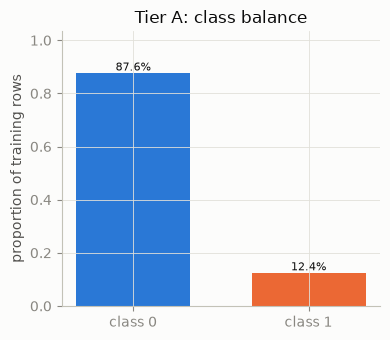

In [5]:
fig, ax = plt.subplots(figsize=(4, 3.5))
bar_with_labels(ax, [f"class {c}" for c in range(geomA.n_classes)], propsA,
                colors=PALETTE["categorical"][:geomA.n_classes])
ax.set_ylabel("proportion of training rows")
ax.set_title("Tier A: class balance")
save_fig(fig, "tierA_class_balance")

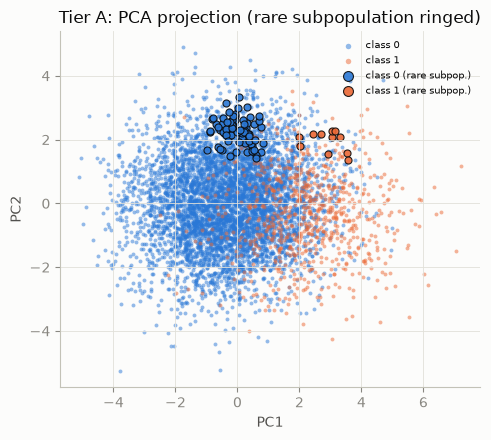

In [6]:
fig, ax = plt.subplots(figsize=(5, 4.5))
coords, idx = pca_project(trainA.X)
y_s, rare_s = trainA.y[idx], trainA.in_rare[idx]

for c in range(geomA.n_classes):
    mask = (y_s == c) & ~rare_s
    ax.scatter(coords[mask, 0], coords[mask, 1], s=8, alpha=0.5,
               color=PALETTE["categorical"][c], label=f"class {c}", linewidths=0)
for c in range(geomA.n_classes):
    mask = (y_s == c) & rare_s
    if mask.any():
        ax.scatter(coords[mask, 0], coords[mask, 1], s=26, alpha=0.9,
                   facecolor=PALETTE["categorical"][c], edgecolor=PALETTE["ink_primary"],
                   linewidths=0.8, label=f"class {c} (rare subpop.)")

ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("Tier A: PCA projection (rare subpopulation ringed)")
ax.legend(frameon=False, fontsize=7, markerscale=1.4)
save_fig(fig, "tierA_pca_scatter")

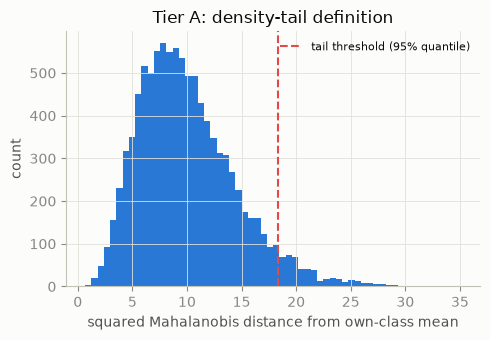

In [7]:
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.hist(trainA.mahalanobis ** 2, bins=60, color=PALETTE["categorical"][0], edgecolor="none")
ax.axvline(geomA.tail_threshold, color=PALETTE["categorical"][7], linewidth=1.5, linestyle="--",
           label=f"tail threshold ({geomA.tail_quantile:.0%} quantile)")
ax.set_xlabel("squared Mahalanobis distance from own-class mean")
ax.set_ylabel("count")
ax.set_title("Tier A: density-tail definition")
ax.legend(frameon=False, fontsize=8)
save_fig(fig, "tierA_mahalanobis_tail")

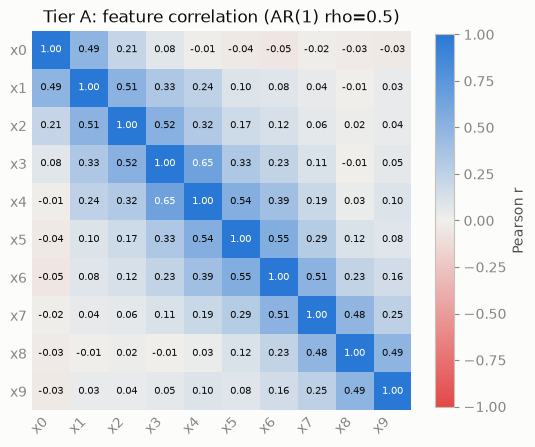

In [8]:
fig, ax = plt.subplots(figsize=(5.5, 5))
corrA = np.corrcoef(trainA.X, rowvar=False)
im = annotated_heatmap(ax, corrA, [f"x{i}" for i in range(geomA.d)])
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson r")
ax.set_title(f"Tier A: feature correlation (AR(1) rho={geomA.params['rho']})")
save_fig(fig, "tierA_correlation_matrix")

## Tier B — Covertype

581,012-row UCI population (`datasets/covertype_dataset.py`), subsampled
50k (`experiments/preprocessing/covertype.py`) preserving the population's
own class balance. Two of its seven forest-cover classes are genuinely
rare (<2% of the population) — the real-data analog of Tier A's rare
subpopulation.

In [9]:
geomC = cover_geometry()
trainC, testC = cover_splits(geomC, n_subsample=50_000, sample_seed=0)

print(f"Covertype: n_train={len(trainC.y)}  n_population={geomC.n_population}")
print("class proportions:", dict(zip(geomC.class_labels.tolist(), geomC.class_props.round(4).tolist())))
print("rare classes:", geomC.rare_classes.tolist())

Covertype: n_train=40000  n_population=581012
class proportions: {0: 0.3646, 1: 0.4876, 2: 0.0615, 3: 0.0047, 4: 0.0163, 5: 0.0299, 6: 0.0353}
rare classes: [3, 4]


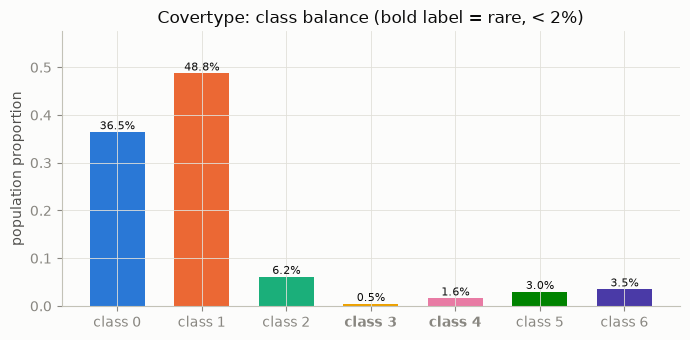

In [10]:
fig, ax = plt.subplots(figsize=(7, 3.5))
colors = PALETTE["categorical"][:len(geomC.class_labels)]
bar_with_labels(ax, [f"class {c}" for c in geomC.class_labels], geomC.class_props, colors=colors)
for i, c in enumerate(geomC.class_labels):
    if c in geomC.rare_classes:
        ax.get_xticklabels()[i].set_fontweight("bold")
ax.set_ylabel("population proportion")
ax.set_title("Covertype: class balance (bold label = rare, < 2%)")
save_fig(fig, "covertype_class_balance")

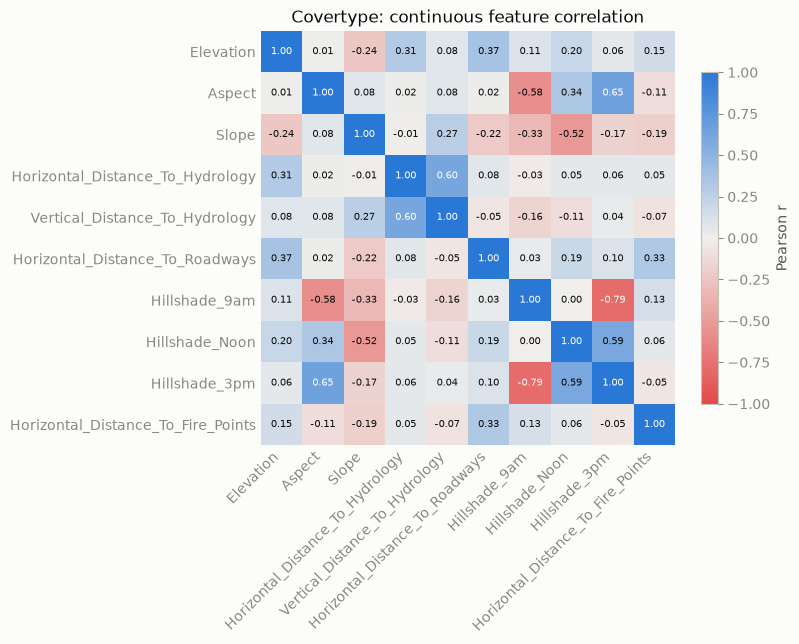

In [11]:
fig, ax = plt.subplots(figsize=(8, 6.5))
corrC = cover_corr(trainC.X)
im = annotated_heatmap(ax, corrC, CONTINUOUS_FEATURE_NAMES)
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson r")
ax.set_title("Covertype: continuous feature correlation", fontsize=12)
save_fig(fig, "covertype_correlation_matrix")

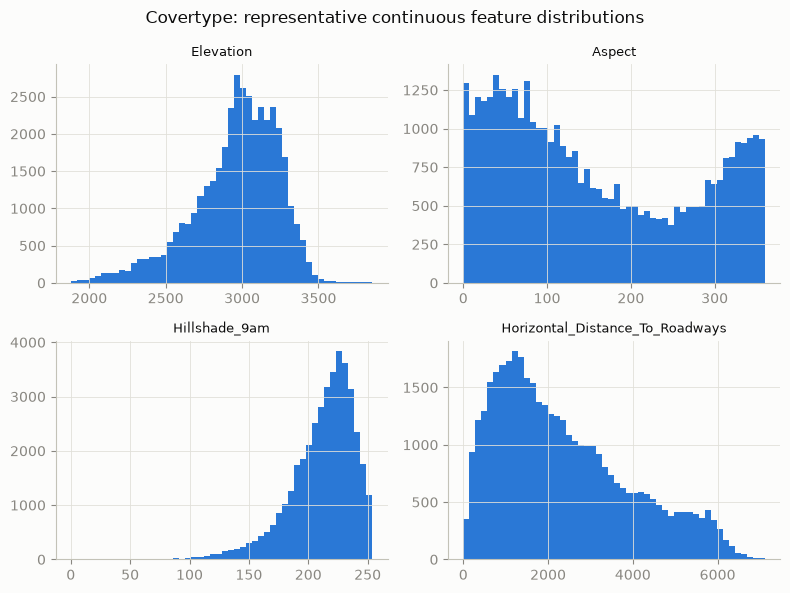

In [12]:
show_idx = [0, 1, 6, 5]  # Elevation, Aspect, Hillshade_9am, Horiz_Dist_To_Roadways
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
cont = cover_cont(trainC.X)
for ax, i in zip(axes.ravel(), show_idx):
    ax.hist(cont[:, i], bins=50, color=PALETTE["categorical"][0], edgecolor="none")
    ax.set_title(CONTINUOUS_FEATURE_NAMES[i], fontsize=9)
fig.suptitle("Covertype: representative continuous feature distributions")
save_fig(fig, "covertype_feature_distributions")

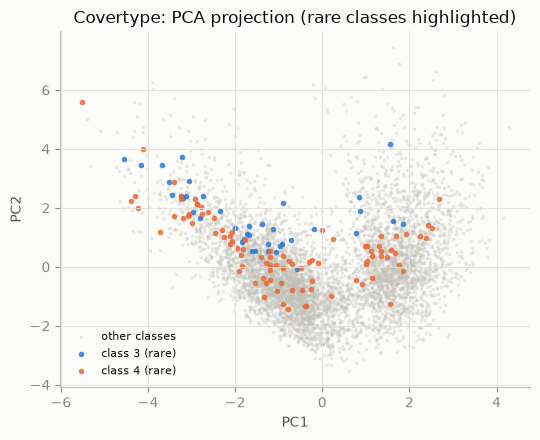

In [13]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
coords, idx = pca_project(cover_cont(trainC.X))
y_s = trainC.y[idx]
rare = geomC.rare_classes

other = ~np.isin(y_s, rare)
ax.scatter(coords[other, 0], coords[other, 1], s=6, alpha=0.35,
           color=PALETTE["other_gray"], label="other classes", linewidths=0)
for i, c in enumerate(rare):
    mask = y_s == c
    ax.scatter(coords[mask, 0], coords[mask, 1], s=16, alpha=0.85,
               color=PALETTE["categorical"][i], label=f"class {c} (rare)", linewidths=0)

ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("Covertype: PCA projection (rare classes highlighted)")
ax.legend(frameon=False, fontsize=8)
save_fig(fig, "covertype_pca_scatter")

## Tier B — Income (Adult / Census Income)

~48,842-row UCI population, ~2.5% dropped for missing values
(`experiments/preprocessing/income.py`). No subsampling — small enough to
use in full. `in_rare` proxies rare *demographic groups* (race categories
below 2% of the population), not a rare target class, since income is
binary and the dataset's actual purpose is tracking minority-group
representation (Wyllie et al.), not class rarity.

In [14]:
geomI = income_geometry()
trainI, testI = income_splits(geomI, sample_seed=0)

print(f"Income: n_train={len(trainI.y)}  n_population={geomI.n_population}  "
      f"dropped_missing={geomI.n_dropped_missing}")

Income: n_train=38097  n_population=47621  dropped_missing=1221


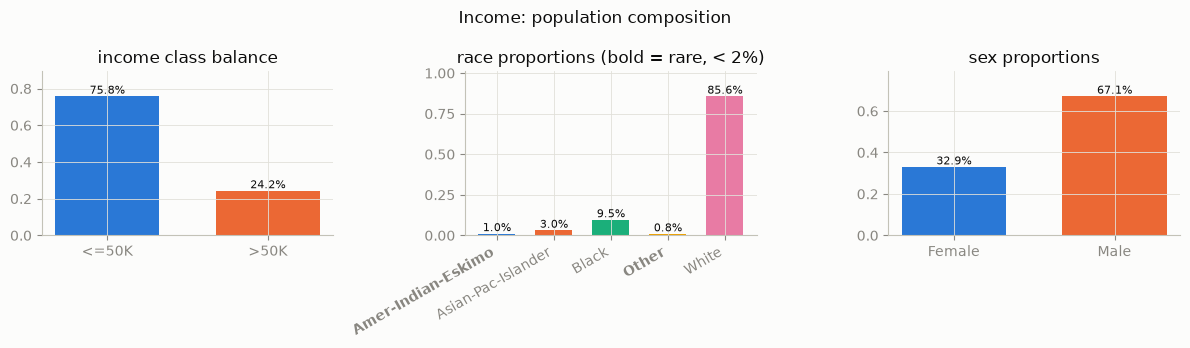

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

bar_with_labels(axes[0], ["<=50K", ">50K"], geomI.class_props, colors=PALETTE["categorical"][:2])
axes[0].set_title("income class balance")

bar_with_labels(axes[1], geomI.race_labels, geomI.race_props,
                colors=PALETTE["categorical"][:len(geomI.race_labels)], rotate=30)
axes[1].set_title("race proportions (bold = rare, < 2%)")
for i, r in enumerate(geomI.race_labels):
    if r in geomI.rare_races:
        axes[1].get_xticklabels()[i].set_fontweight("bold")

bar_with_labels(axes[2], geomI.sex_labels, geomI.sex_props, colors=PALETTE["categorical"][:2])
axes[2].set_title("sex proportions")

fig.suptitle("Income: population composition")
save_fig(fig, "income_population_composition")

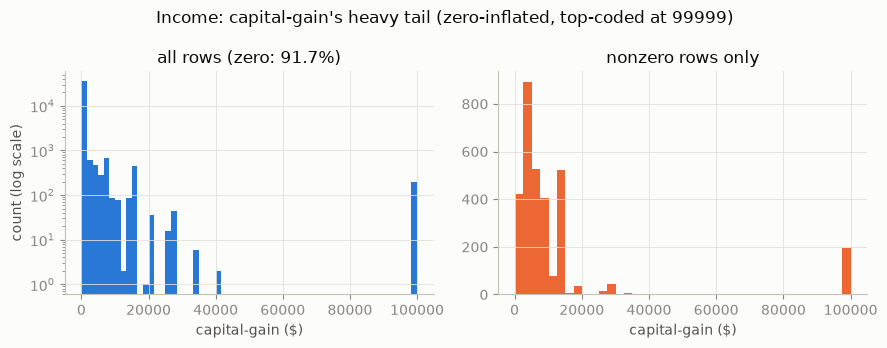

In [16]:
cg = income_cont(trainI.X)[:, CONTINUOUS_COLUMNS.index("capital-gain")]
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

axes[0].hist(cg, bins=60, color=PALETTE["categorical"][0], edgecolor="none")
axes[0].set_yscale("log")
axes[0].set_title(f"all rows (zero: {(cg == 0).mean():.1%})")
axes[0].set_xlabel("capital-gain ($)"); axes[0].set_ylabel("count (log scale)")

axes[1].hist(cg[cg > 0], bins=40, color=PALETTE["categorical"][1], edgecolor="none")
axes[1].set_title("nonzero rows only")
axes[1].set_xlabel("capital-gain ($)")

fig.suptitle("Income: capital-gain's heavy tail (zero-inflated, top-coded at 99999)")
save_fig(fig, "income_capital_gain_tail")

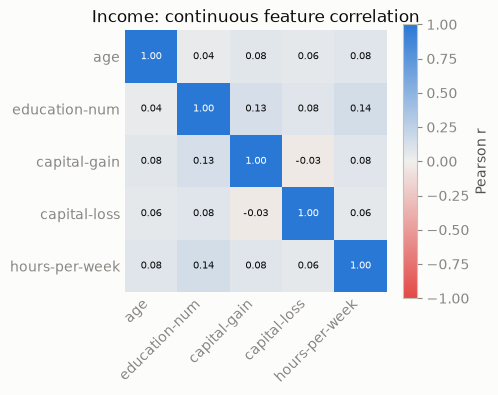

In [17]:
fig, ax = plt.subplots(figsize=(5, 4.5))
corrI = income_corr(trainI.X)
im = annotated_heatmap(ax, corrI, CONTINUOUS_COLUMNS)
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson r")
ax.set_title("Income: continuous feature correlation")
save_fig(fig, "income_correlation_matrix")

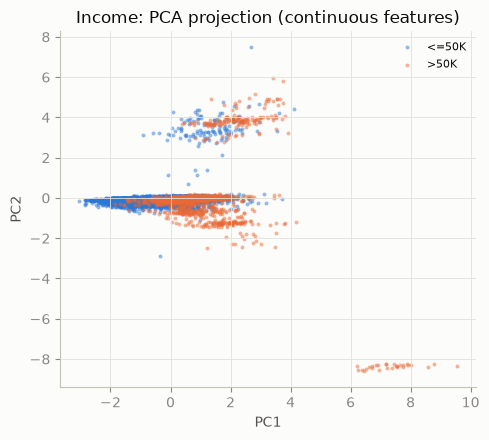

In [18]:
fig, ax = plt.subplots(figsize=(5, 4.5))
coords, idx = pca_project(income_cont(trainI.X))
y_s = trainI.y[idx]
for c, name, color in [(0, "<=50K", PALETTE["categorical"][0]), (1, ">50K", PALETTE["categorical"][1])]:
    mask = y_s == c
    ax.scatter(coords[mask, 0], coords[mask, 1], s=8, alpha=0.5, color=color, label=name, linewidths=0)

ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("Income: PCA projection (continuous features)")
ax.legend(frameon=False, fontsize=8)
save_fig(fig, "income_pca_scatter")

## Summary table

One row per dataset, for a compact appendix table alongside the figures.

In [19]:
summary = pd.DataFrame([
    {
        "dataset": "Tier A (synthetic)", "n_train": len(trainA.y), "d_total": geomA.d,
        "n_continuous": geomA.d, "n_classes": geomA.n_classes,
        "majority_pct": propsA.max(), "minority_pct": propsA.min(),
        "rare_group_pct": trainA.in_rare.mean(),
    },
    {
        "dataset": "Covertype (Tier B)", "n_train": len(trainC.y), "d_total": trainC.X.shape[1],
        "n_continuous": len(CONTINUOUS_FEATURE_NAMES), "n_classes": len(geomC.class_labels),
        "majority_pct": geomC.class_props.max(), "minority_pct": geomC.class_props.min(),
        "rare_group_pct": trainC.in_rare.mean(),
    },
    {
        "dataset": "Income (Tier B)", "n_train": len(trainI.y), "d_total": trainI.X.shape[1],
        "n_continuous": len(CONTINUOUS_COLUMNS), "n_classes": len(geomI.class_labels),
        "majority_pct": geomI.class_props.max(), "minority_pct": geomI.class_props.min(),
        "rare_group_pct": trainI.in_rare.mean(),
    },
])

summary.to_csv(FIGURES_DIR / "dataset_summary.csv", index=False)
print(summary.to_string(index=False))
print()
print(summary.to_latex(index=False, float_format="%.3f"))

           dataset  n_train  d_total  n_continuous  n_classes  majority_pct  minority_pct  rare_group_pct
Tier A (synthetic)    10000       10            10          2      0.875900      0.124100        0.015000
Covertype (Tier B)    40000       54            10          7      0.487599      0.004728        0.020775
   Income (Tier B)    38097       91             5          2      0.757649      0.242351        0.017823

\begin{tabular}{lrrrrrrr}
\toprule
dataset & n_train & d_total & n_continuous & n_classes & majority_pct & minority_pct & rare_group_pct \\
\midrule
Tier A (synthetic) & 10000 & 10 & 10 & 2 & 0.876 & 0.124 & 0.015 \\
Covertype (Tier B) & 40000 & 54 & 10 & 7 & 0.488 & 0.005 & 0.021 \\
Income (Tier B) & 38097 & 91 & 5 & 2 & 0.758 & 0.242 & 0.018 \\
\bottomrule
\end{tabular}

